In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (3).json


{'kaggle (3).json': b'{"username":"malakali19","key":"675ce47670940193b733610edc8daa7d"}'}

In [ ]:
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d mrwellsdavid/unsw-nb15 -f UNSW_NB15_training-set.csv

Dataset URL: https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
License(s): unknown
UNSW_NB15_training-set.csv.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip UNSW_NB15_training-set.csv.zip

Archive:  UNSW_NB15_training-set.csv.zip
replace UNSW_NB15_training-set.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


Data Exploration

In [ ]:
import pandas as pd

df = pd.read_csv("UNSW_NB15_training-set.csv")
df

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.090200,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.000300,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.005100,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.660800,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.002500,...,1,3,0,0,0,2,3,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82327,82328,0.000005,udp,-,INT,2,0,104,0,200000.005100,...,1,2,0,0,0,2,1,0,Normal,0
82328,82329,1.106101,tcp,-,FIN,20,8,18062,354,24.410067,...,1,1,0,0,0,3,2,0,Normal,0
82329,82330,0.000000,arp,-,INT,1,0,46,0,0.000000,...,1,1,0,0,0,1,1,1,Normal,0
82330,82331,0.000000,arp,-,INT,1,0,46,0,0.000000,...,1,1,0,0,0,1,1,1,Normal,0


In [ ]:
df.columns

Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')

In [ ]:
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [ ]:
df.shape

(82332, 45)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

In [ ]:
df.isnull().sum()

,0
id,0
dur,0
proto,0
service,0
state,0
spkts,0
dpkts,0
sbytes,0
dbytes,0
rate,0


In [ ]:
df['service'].value_counts()

,count
service,
-,47153
dns,21367
http,8287
smtp,1851
ftp,1552
ftp-data,1396
pop3,423
ssh,204
ssl,30


In [ ]:
df['label'].value_counts()

,count
label,
1,45332
0,37000


In [ ]:
df['attack_cat'].value_counts()

,count
attack_cat,
Normal,37000
Generic,18871
Exploits,11132
Fuzzers,6062
DoS,4089
Reconnaissance,3496
Analysis,677
Backdoor,583
Shellcode,378


Data Cleaning + Preprocessing

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['service'] = df['service'].replace('-', 'dns')


In [ ]:
df['service'].value_counts()

,count
service,
dns,68520
http,8287
smtp,1851
ftp,1552
ftp-data,1396
pop3,423
ssh,204
ssl,30
snmp,29


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

⁠visualization (EDA)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

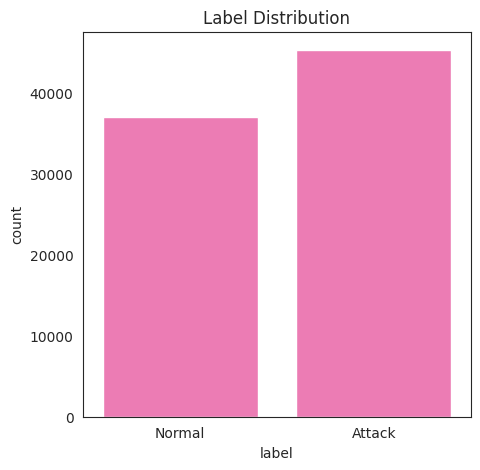

In [ ]:
sns.countplot(x='label', data=df, color="#ff69b4")
plt.title("Label Distribution" )
plt.xticks([0,1], ['Normal','Attack'])
plt.show()

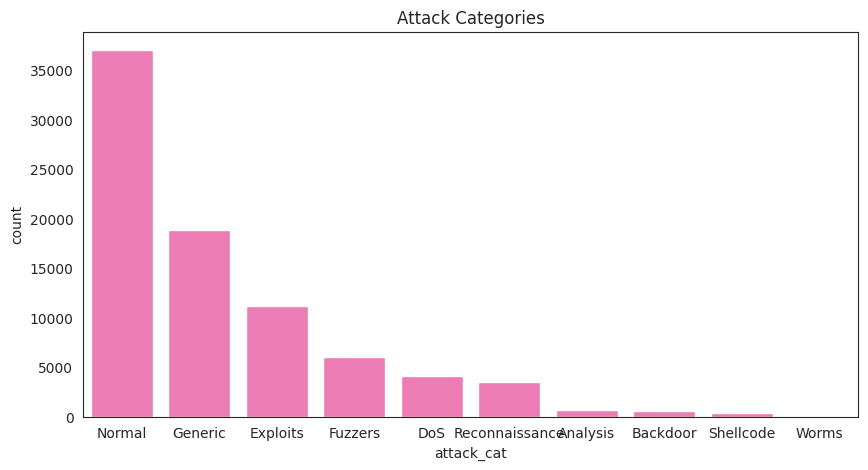

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='attack_cat', data=df,
             order=df['attack_cat'].value_counts().index , color="#ff69b4")

plt.title("Attack Categories")
plt.show()

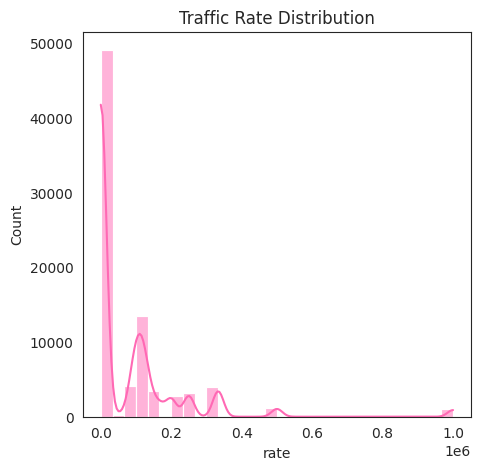

In [ ]:
sns.histplot(df['rate'], bins=30, kde=True, color="#ff69b4")

plt.title("Traffic Rate Distribution")
plt.show()

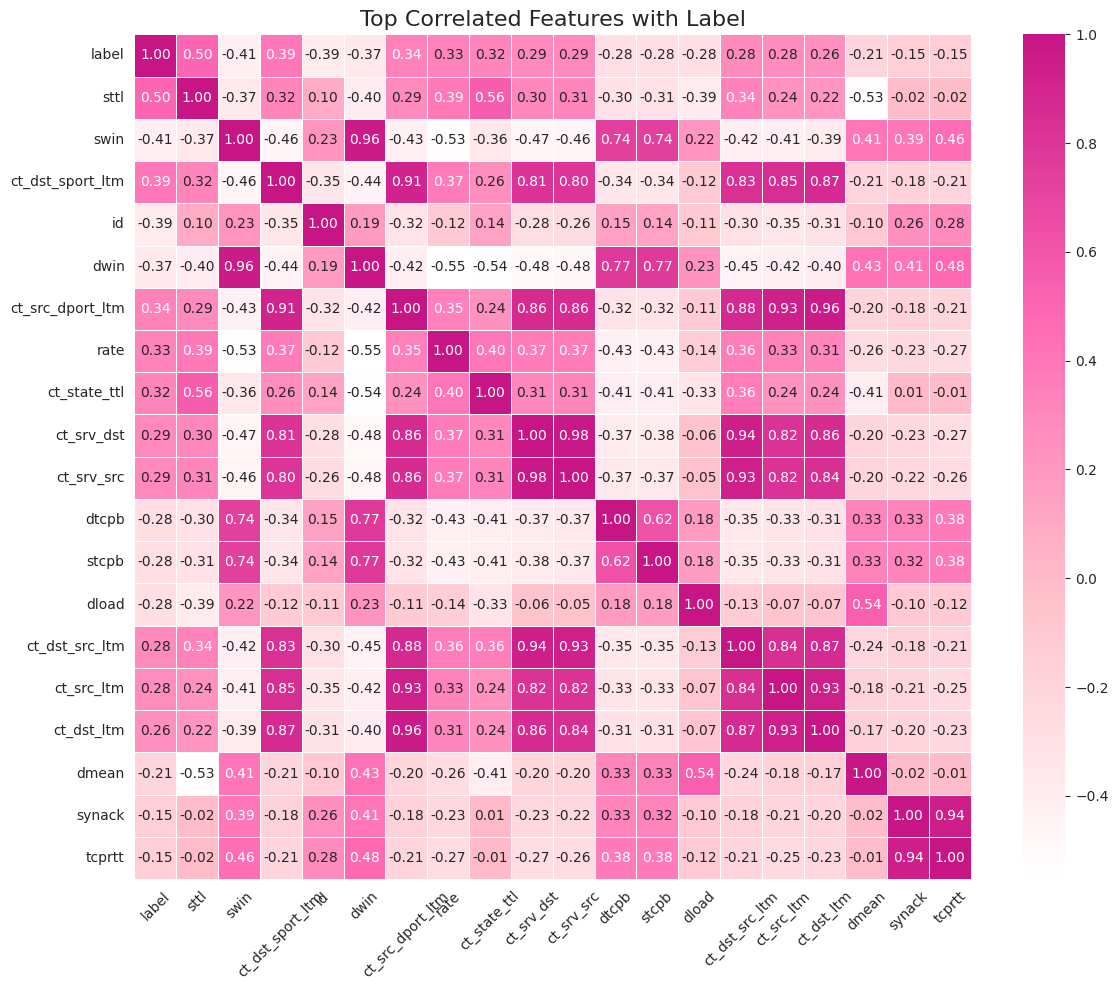

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_numeric = df.select_dtypes(include=['number'])

corr = df_numeric.corr()

top_features = corr['label'].abs().sort_values(ascending=False).head(20).index
corr_top = df_numeric[top_features].corr()

pink_cmap = LinearSegmentedColormap.from_list(
    "pink_palette",
    ["#ffffff", "#ffc0cb", "#ff69b4", "#c71585"])

plt.figure(figsize=(12,10))
sns.heatmap(
    corr_top,
    annot=True,
    cmap=pink_cmap,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Top Correlated Features with Label", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

outliers


In [ ]:
import numpy as np

numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['label'])

In [ ]:
def remove_outliers_iqr(df, cols):
    df_clean = df.copy()

    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

    return df_clean

Train/Test Split

In [ ]:
X = df.drop(columns=['label', 'attack_cat', 'id'])
y = df['label']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = X.select_dtypes(include=['object']).columns

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

X_train_num = X_train.drop(columns=categorical_cols).values
X_test_num = X_test.drop(columns=categorical_cols).values

X_train_final = np.hstack([X_train_num, X_train_cat])
X_test_final = np.hstack([X_test_num, X_test_cat])

feature_names = list(X_train.drop(columns=categorical_cols).columns) + \
                list(encoder.get_feature_names_out(categorical_cols))



Model before Feature Selection

model 1 (RandomForestClassifier)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_final, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test_final)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

acc_before = accuracy_score(y_test, y_pred)

print("=== BEFORE FEATURE SELECTION ===")
print("Accuracy:", acc_before)
print(classification_report(y_test, y_pred))

=== BEFORE FEATURE SELECTION ===
Accuracy: 0.9764984514483512
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      7400
           1       0.98      0.97      0.98      9067

    accuracy                           0.98     16467
   macro avg       0.98      0.98      0.98     16467
weighted avg       0.98      0.98      0.98     16467



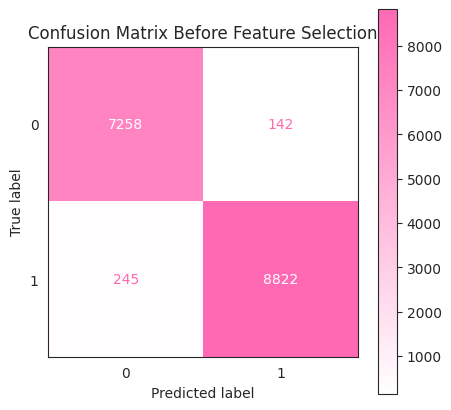

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_pink",
    ["#ffffff", "#ff69b4"])

plt.rcParams['figure.figsize'] = (5, 5)
sns.set_style("white")

disp = ConfusionMatrixDisplay.from_estimator(
    model,
    X_test_final,
    y_test,
    cmap=custom_cmap
)

plt.title("Confusion Matrix Before Feature Selection")
plt.show()

Hyperparameter Visualization

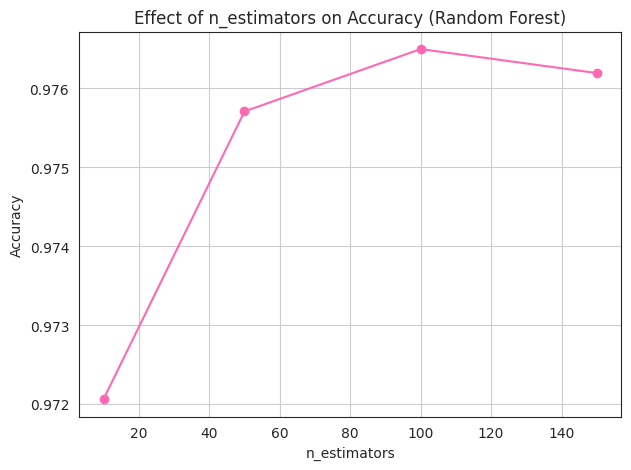

In [ ]:
estimators = [10, 50, 100, 150]
scores = []

for n in estimators:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train_final, y_train)
    scores.append(model.score(X_test_final, y_test))

plt.figure(figsize=(7,5))
plt.plot(estimators, scores, marker='o', color="#ff69b4")
plt.title("Effect of n_estimators on Accuracy (Random Forest)")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

Feature Importance Before Selection

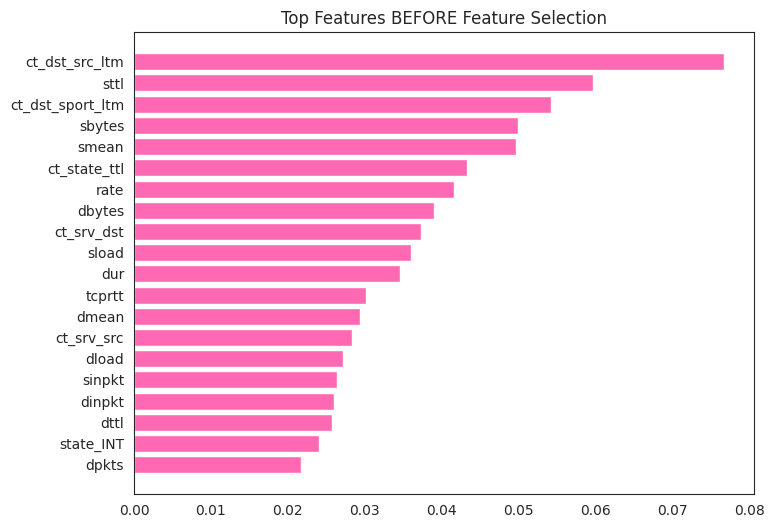

In [ ]:
importances_before = model.feature_importances_

feat_imp_before = pd.DataFrame({
    "feature": feature_names,
    "importance": importances_before
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(8,6))
plt.barh(feat_imp_before['feature'][:20],
         feat_imp_before['importance'][:20],
         color="#ff69b4")

plt.gca().invert_yaxis()
plt.title("Top Features BEFORE Feature Selection")
plt.show()

Feature Selection(RANDOM FOREST IMPORTANCE)

In [ ]:
selector_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
selector_model.fit(X_train_final, y_train)

importances = selector_model.feature_importances_

idx = np.argsort(importances)[-30:]

X_train_fs = X_train_final[:, idx]
X_test_fs = X_test_final[:, idx]

selected_features = [feature_names[i] for i in idx]

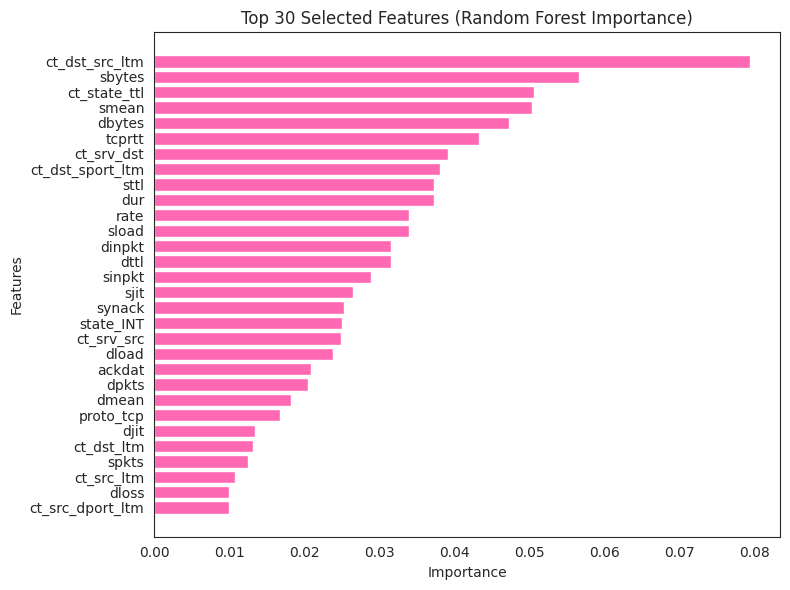

In [ ]:
feat_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

top_features = feat_df.iloc[idx].sort_values(by="importance", ascending=True)

plt.figure(figsize=(8,6))

plt.barh(top_features["feature"],
         top_features["importance"],
         color="#ff69b4")

plt.title("Top 30 Selected Features (Random Forest Importance)")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

FEATURE IMPORTANCE AFTER Selection

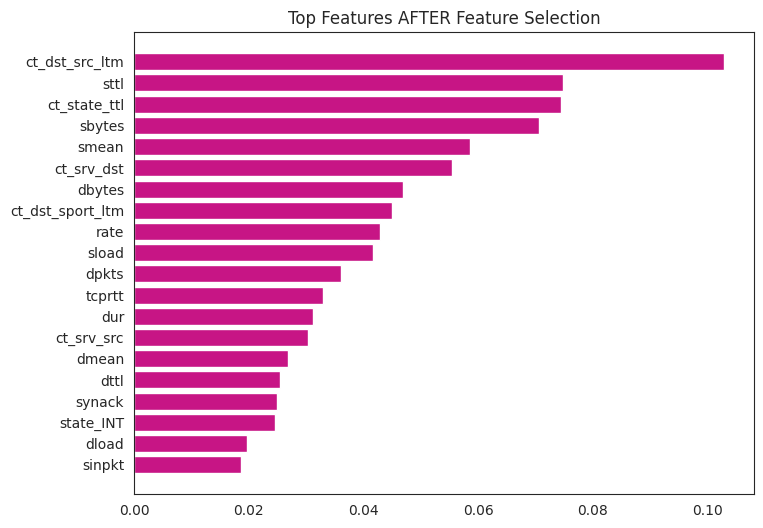

In [ ]:
#da feature imporance b3d el feature selection
selector_model.fit(X_train_fs, y_train)

feat_imp_after = pd.DataFrame({
    "feature": selected_features,
    "importance": selector_model.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(8,6))
plt.barh(feat_imp_after['feature'][:20],
         feat_imp_after['importance'][:20],
         color="#c71585")

plt.gca().invert_yaxis()
plt.title("Top Features AFTER Feature Selection")
plt.show()

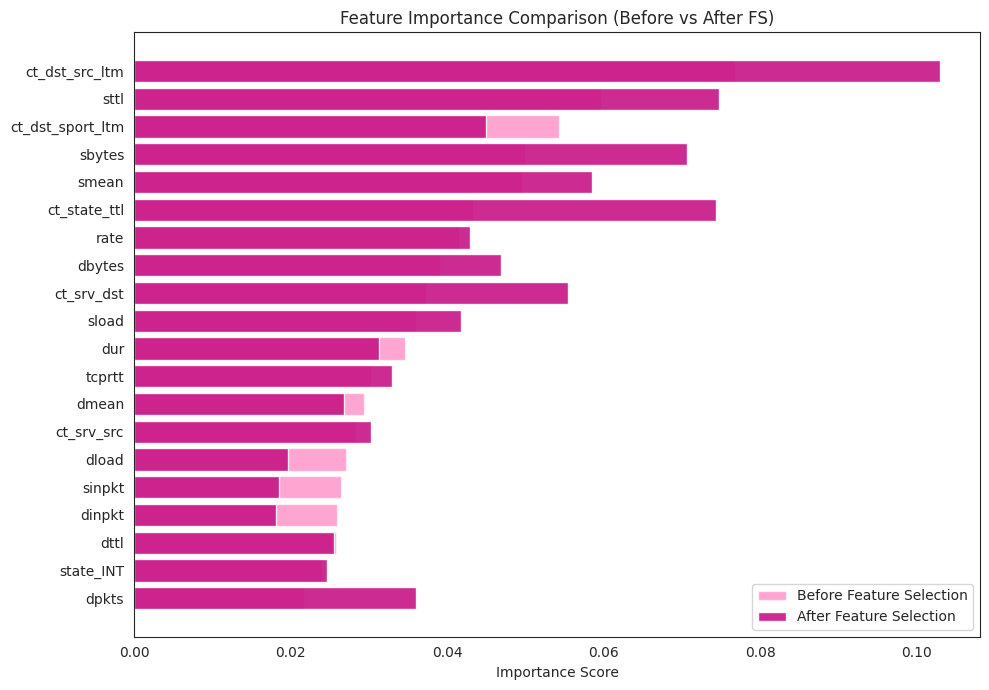

In [ ]:
#plot by3ml mokarna bin 2bl w b3d el feature selection

# 2bl FEATURE IMPORTANCE
feat_imp_before = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

top_before = feat_imp_before.head(20)

# B3d FEATURE IMPORTANCE
feat_imp_after = pd.DataFrame({
    "feature": selected_features,
    "importance": selector_model.feature_importances_
}).sort_values(by="importance", ascending=False)

after_dict = dict(zip(feat_imp_after["feature"], feat_imp_after["importance"]))

after_values = [after_dict.get(f, 0) for f in top_before["feature"]]

#mokarna plot
plt.figure(figsize=(10,7))

y_pos = np.arange(len(top_before))

plt.barh(y_pos, top_before["importance"],
         color="#ff69b4", alpha=0.6, label="Before Feature Selection")

plt.barh(y_pos, after_values,
         color="#c71585", alpha=0.9, label="After Feature Selection")

plt.yticks(y_pos, top_before["feature"])
plt.gca().invert_yaxis()

plt.title("Feature Importance Comparison (Before vs After FS)")
plt.xlabel("Importance Score")

plt.legend()
plt.tight_layout()
plt.show()

ReTraining Model After Feature Selection

model 1 (RandomForestClassifier)

In [ ]:
X_train_fs = X_train_final[:, idx]
X_test_fs = X_test_fs = X_test_final[:, idx]

In [ ]:
model_fs = RandomForestClassifier(random_state=42, n_estimators=100)
model_fs.fit(X_train_fs, y_train)

y_pred_fs = model_fs.predict(X_test_fs)
acc_after = accuracy_score(y_test, y_pred_fs)

print("\n=== AFTER FEATURE SELECTION ===")
print("Accuracy:", acc_after)
print(classification_report(y_test, y_pred_fs))


=== AFTER FEATURE SELECTION ===
Accuracy: 0.9747980810105059
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      7400
           1       0.98      0.97      0.98      9067

    accuracy                           0.97     16467
   macro avg       0.97      0.98      0.97     16467
weighted avg       0.97      0.97      0.97     16467



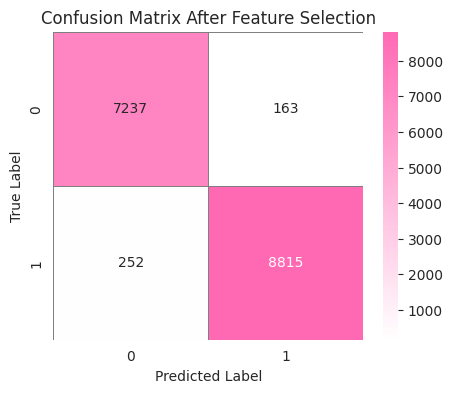

In [ ]:
plt.figure(figsize=(5,4))
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_pink",
    ["#ffffff", "#ff69b4"])

plt.rcParams['figure.figsize'] = (5, 5)
sns.set_style("white")

sns.heatmap(confusion_matrix(y_test, y_pred_fs), annot=True, fmt="d", cmap=custom_cmap,linewidths=0.5,
    linecolor="gray",cbar=True)

plt.title("Confusion Matrix After Feature Selection")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()


In [ ]:
from sklearn.model_selection import cross_val_score

scores_before = cross_val_score(model, X_train_final, y_train, cv=5 ,n_jobs=-1)
acc_before = scores_before.mean()


scores_after = cross_val_score(model_fs, X_train_fs, y_train, cv=5,n_jobs=-1)
acc_after = scores_after.mean()


print("\n=== CROSS VALIDATION ===")
print("Before FS:", scores_before.mean())
print("After FS:", scores_after.mean())


=== CROSS VALIDATION ===
Before FS: 0.9758141653381918
After FS: 0.9753738707963258


In [ ]:
results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Before Feature Selection": [acc_before],
    "After Feature Selection": [acc_after],
    "CV Before": [scores_before.mean()],
    "CV After": [scores_after.mean()]
})

print(results)

           Model  Before Feature Selection  After Feature Selection  \
0  Random Forest                  0.975814                 0.975374   

   CV Before  CV After  
0   0.975814  0.975374  


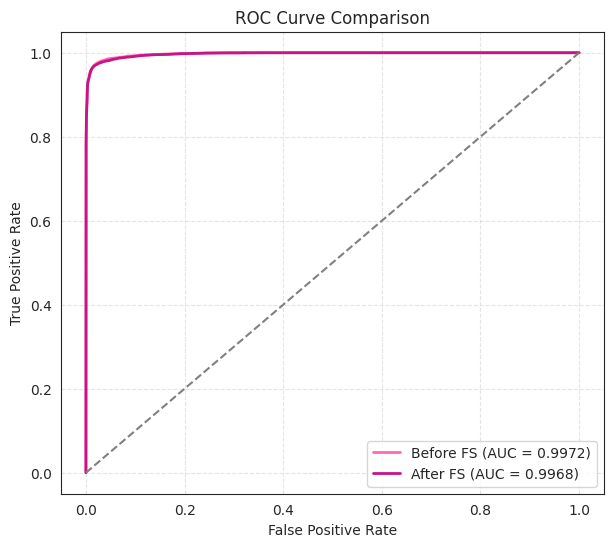

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_score_before = model.predict_proba(X_test_final)[:, 1]
y_score_after = model_fs.predict_proba(X_test_fs)[:, 1]


fpr_before, tpr_before, _ = roc_curve(y_test, y_score_before)
roc_auc_before = auc(fpr_before, tpr_before)


fpr_after, tpr_after, _ = roc_curve(y_test, y_score_after)
roc_auc_after = auc(fpr_after, tpr_after)


plt.figure(figsize=(7,6))

plt.plot(
    fpr_before, tpr_before,
    color="#ff69b4",
    label=f"Before FS (AUC = {roc_auc_before:.4f})",
    linewidth=2)

plt.plot(
    fpr_after, tpr_after,
    color="#c71585",
    label=f"After FS (AUC = {roc_auc_after:.4f})",
    linewidth=2)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

model 2 (Decision Tree)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)

dt_model.fit(X_train_final, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test_final)

In [ ]:
acc_before = accuracy_score(y_test, y_pred_dt)

print("=== BEFORE FEATURE SELECTION ===")
print("Accuracy:", acc_before)
print(classification_report(y_test, y_pred_dt))

=== BEFORE FEATURE SELECTION ===
Accuracy: 0.9596769296168094
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      7400
           1       0.98      0.95      0.96      9067

    accuracy                           0.96     16467
   macro avg       0.96      0.96      0.96     16467
weighted avg       0.96      0.96      0.96     16467



Decision Tree max_depth

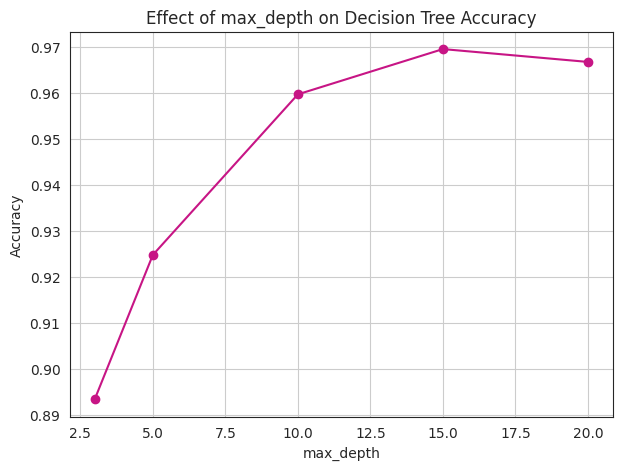

In [ ]:
depths = [3, 5, 10, 15, 20]
scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train_final, y_train)
    scores.append(model.score(X_test_final, y_test))

plt.figure(figsize=(7,5))
plt.plot(depths, scores, marker='o', color="#c71585")
plt.title("Effect of max_depth on Decision Tree Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

Feature Importance 2 Before Selection

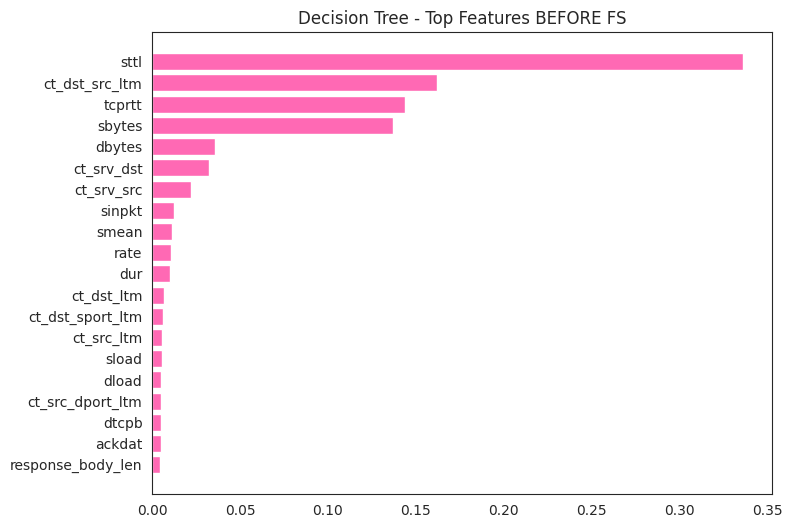

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_final, y_train)

importances_before_dt = dt_model.feature_importances_

feat_imp_before_dt = pd.DataFrame({
    "feature": feature_names,
    "importance": importances_before_dt
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(8,6))
plt.barh(feat_imp_before_dt['feature'][:20],
         feat_imp_before_dt['importance'][:20],
         color="#ff69b4")

plt.gca().invert_yaxis()
plt.title("Decision Tree - Top Features BEFORE FS")
plt.show()

Feature Importance 2 After Selection

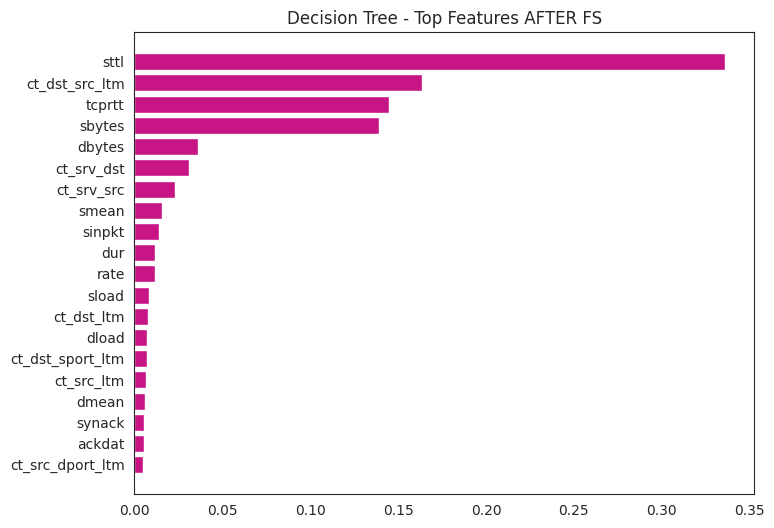

In [ ]:
dt_model_fs = DecisionTreeClassifier(random_state=42)
dt_model_fs.fit(X_train_fs, y_train)

importances_after_dt = dt_model_fs.feature_importances_

feat_imp_after_dt = pd.DataFrame({
    "feature": selected_features,
    "importance": importances_after_dt
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(8,6))
plt.barh(feat_imp_after_dt['feature'][:20],
         feat_imp_after_dt['importance'][:20],
         color="#c71585")

plt.gca().invert_yaxis()
plt.title("Decision Tree - Top Features AFTER FS")
plt.show()

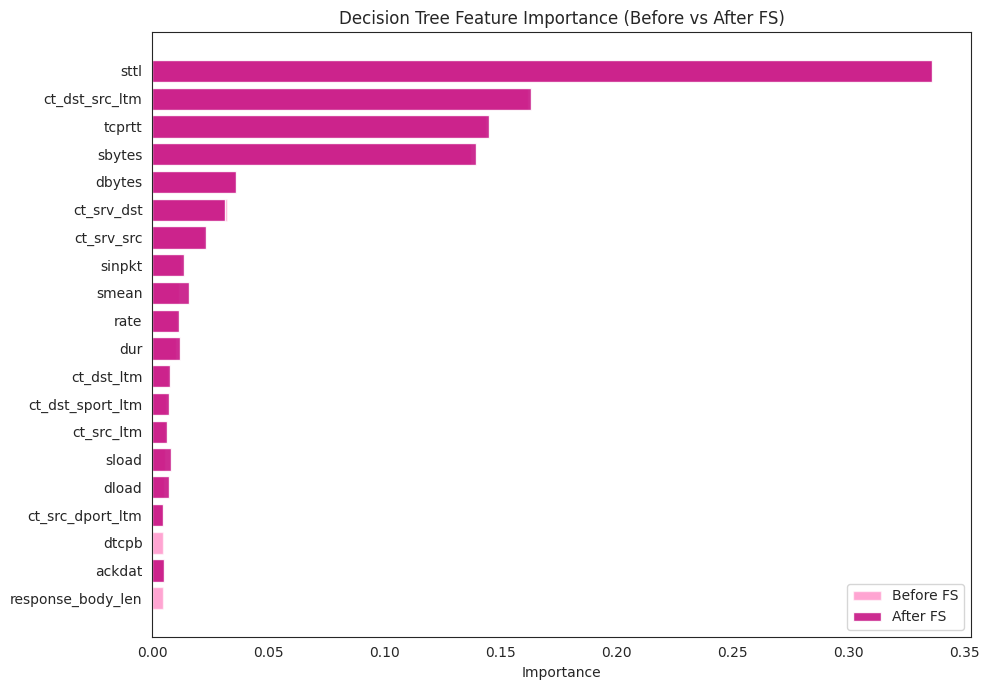

In [ ]:
#plot by3ml mokarna bin 2bl w b3d el feature selection
# Before
feat_imp_before_dt = pd.DataFrame({
    "feature": feature_names,
    "importance": dt_model.feature_importances_
}).sort_values(by="importance", ascending=False)

top_before_dt = feat_imp_before_dt.head(20)

# After
feat_imp_after_dt = pd.DataFrame({
    "feature": selected_features,
    "importance": dt_model_fs.feature_importances_
}).sort_values(by="importance", ascending=False)

after_dict_dt = dict(zip(
    feat_imp_after_dt["feature"],
    feat_imp_after_dt["importance"]
))

after_values_dt = [
    after_dict_dt.get(f, 0)
    for f in top_before_dt["feature"]
]

plt.figure(figsize=(10,7))

y_pos = np.arange(len(top_before_dt))

plt.barh(y_pos,
         top_before_dt["importance"],
         color="#ff69b4",
         alpha=0.6,
         label="Before FS")

plt.barh(y_pos,
         after_values_dt,
         color="#c71585",
         alpha=0.9,
         label="After FS")

plt.yticks(y_pos, top_before_dt["feature"])
plt.gca().invert_yaxis()

plt.title("Decision Tree Feature Importance (Before vs After FS)")
plt.xlabel("Importance")

plt.legend()
plt.tight_layout()
plt.show()

ReTraining Model 2 After Feature Selection

model 2 (DecicionTreeClassifier)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
X_train_fs = X_train_final[:, idx]
X_test_fs  = X_test_final[:, idx]

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train_fs, y_train)

y_pred_dt = model_dt.predict(X_test_fs)

acc_dt = accuracy_score(y_test, y_pred_dt)

print("\n=== DECISION TREE AFTER FEATURE SELECTION ===")
print("Accuracy:", acc_dt)
print(classification_report(y_test, y_pred_dt))


=== DECISION TREE AFTER FEATURE SELECTION ===
Accuracy: 0.9632598530394122
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      7400
           1       0.97      0.97      0.97      9067

    accuracy                           0.96     16467
   macro avg       0.96      0.96      0.96     16467
weighted avg       0.96      0.96      0.96     16467



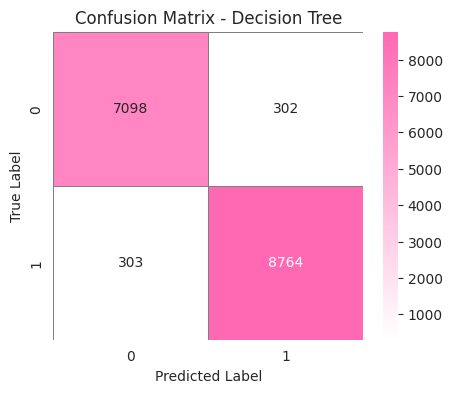

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

plt.figure(figsize=(5,4))

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_pink",
    ["#ffffff", "#ff69b4"]
)
plt.rcParams['figure.figsize'] = (5, 5)
sns.set_style("white")

sns.heatmap(confusion_matrix(y_test, y_pred_dt),
            annot=True,
            fmt='d',
            cmap=custom_cmap,
            linewidths=0.5,
            linecolor='gray',
            cbar=True)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model_fs = DecisionTreeClassifier(random_state=42)

scores_before_dt = cross_val_score(dt_model, X_train_final, y_train, cv=5, n_jobs=-1)
acc_before_dt = scores_before_dt.mean()

scores_after_dt = cross_val_score(dt_model_fs, X_train_fs, y_train, cv=5, n_jobs=-1)
acc_after_dt = scores_after_dt.mean()

print("\n=== DECISION TREE CROSS VALIDATION ===")
print("Before FS:", acc_before_dt)
print("After FS:", acc_after_dt)


=== DECISION TREE CROSS VALIDATION ===
Before FS: 0.9642905943976314
After FS: 0.9632126318985803


In [ ]:
results_dt = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Before Feature Selection": [acc_before_dt],
    "After Feature Selection": [acc_after_dt],
    "CV Before": [acc_before_dt],
    "CV After": [acc_after_dt]})

print(results_dt)

           Model  Before Feature Selection  After Feature Selection  \
0  Decision Tree                  0.964291                 0.963213   

   CV Before  CV After  
0   0.964291  0.963213  


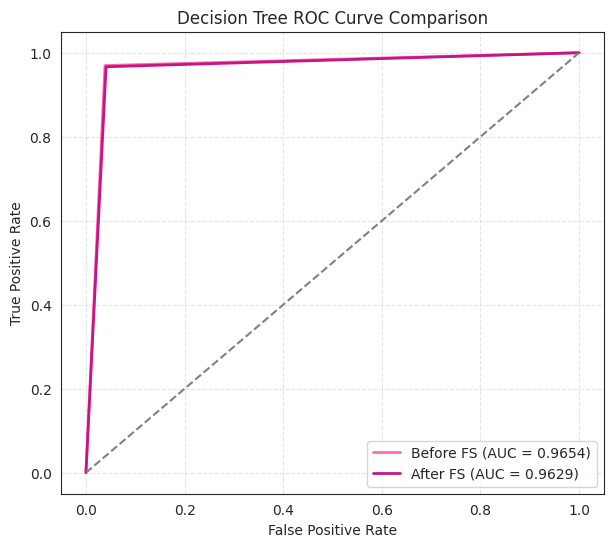

In [ ]:
dt_model.fit(X_train_final, y_train)
dt_model_fs.fit(X_train_fs, y_train)

y_score_before_dt = dt_model.predict_proba(X_test_final)[:, 1]
y_score_after_dt = dt_model_fs.predict_proba(X_test_fs)[:, 1]

fpr_before_dt, tpr_before_dt, _ = roc_curve(y_test, y_score_before_dt)
roc_auc_before_dt = auc(fpr_before_dt, tpr_before_dt)

fpr_after_dt, tpr_after_dt, _ = roc_curve(y_test, y_score_after_dt)
roc_auc_after_dt = auc(fpr_after_dt, tpr_after_dt)

plt.figure(figsize=(7,6))

plt.plot(
    fpr_before_dt, tpr_before_dt,
    color="#ff69b4",
    label=f"Before FS (AUC = {roc_auc_before_dt:.4f})",
    linewidth=2
)

plt.plot(
    fpr_after_dt, tpr_after_dt,
    color="#c71585",
    label=f"After FS (AUC = {roc_auc_after_dt:.4f})",
    linewidth=2
)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.title("Decision Tree ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Final Result Comparison

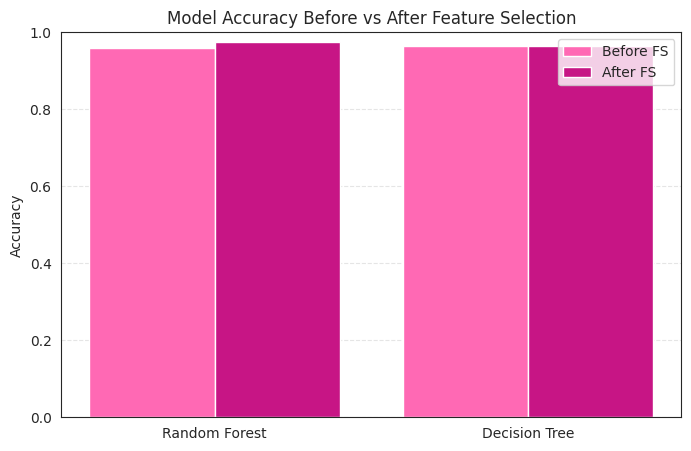

In [ ]:
models = ["Random Forest", "Decision Tree"]

before_scores = [acc_before, acc_before_dt]
after_scores = [acc_after, acc_after_dt]

x = range(len(models))

plt.figure(figsize=(8,5))

plt.bar(x, before_scores, width=0.4, label="Before FS", color="#ff69b4")
plt.bar([i + 0.4 for i in x], after_scores, width=0.4, label="After FS", color="#c71585")

plt.xticks([i + 0.2 for i in x], models)
plt.ylim(0, 1)

plt.title("Model Accuracy Before vs After Feature Selection")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

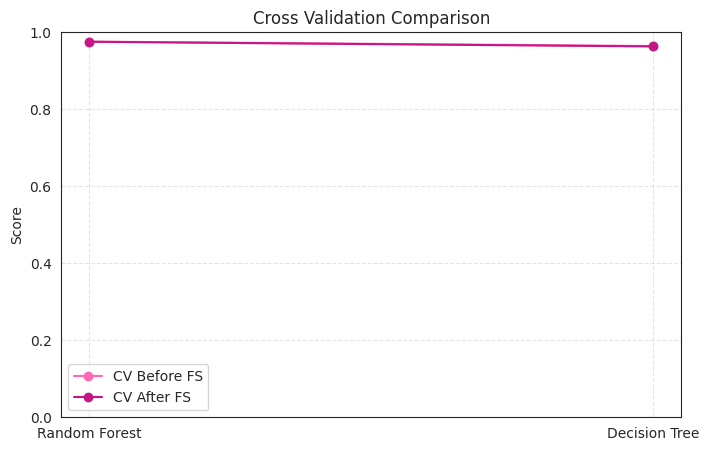

In [ ]:
cv_before = [scores_before.mean(), scores_before_dt.mean()]
cv_after = [scores_after.mean(), scores_after_dt.mean()]

plt.figure(figsize=(8,5))

plt.plot(models, cv_before, marker='o', label="CV Before FS", color="#ff69b4")
plt.plot(models, cv_after, marker='o', label="CV After FS", color="#c71585")

plt.ylim(0, 1)
plt.title("Cross Validation Comparison")
plt.ylabel("Score")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
import pandas as pd

final_results = pd.DataFrame({
    "Model": models,
    "Accuracy Before FS": before_scores,
    "Accuracy After FS": after_scores,
    "CV Before FS": cv_before,
    "CV After FS": cv_after
})

print(final_results)

           Model  Accuracy Before FS  Accuracy After FS  CV Before FS  \
0  Random Forest            0.959677           0.975374      0.975814   
1  Decision Tree            0.964291           0.963213      0.964291   

   CV After FS  
0     0.975374  
1     0.963213  


**The End**